In [0]:
%python
import pandas as pd

matches = spark.table('workspace.`ipl2026-completedataset`.matches').toPandas()
deliveries = spark.table('workspace.`ipl2026-completedataset`.deliveries').toPandas()
points = spark.table('workspace.`ipl2026-completedataset`.points_table').toPandas()
batting = spark.table('workspace.`ipl2026-completedataset`.batting_stats').toPandas()
bowling = spark.table('workspace.`ipl2026-completedataset`.bowling_stats').toPandas()
fielding = spark.table('workspace.`ipl2026-completedataset`.fielding_stats').toPandas()

In [0]:
%python
squads = spark.table('workspace.`ipl2026-completedataset`.squads').toPandas()
venues = spark.table('workspace.`ipl2026-completedataset`.venues').toPandas()

In [0]:
%python
import pandas as pd

print("Matches DataFrame Info:")
print(matches.dtypes)
print("\nDescriptive Statistics:")
print(matches.describe())
print("\nNull Count per Column:")
print(matches.isnull().sum())

Matches DataFrame Info:
match_id                 int64
date                    object
venue                   object
team1                   object
team2                   object
stage                   object
toss_winner             object
toss_decision           object
first_ings_score       float64
first_ings_wkts        float64
second_ings_score      float64
second_ings_wkts       float64
match_result            object
match_winner            object
wb_runs                float64
wb_wickets             float64
balls_left             float64
player_of_the_match     object
top_scorer              object
highscore              float64
best_bowling            object
best_bowling_figure     object
_rescued_data           object
dtype: object

Descriptive Statistics:
        match_id  first_ings_score  ...  balls_left  highscore
count  15.000000         14.000000  ...   14.000000  14.000000
mean    8.000000        186.071429  ...   10.428571  71.857143
std     4.472136         36.833230 

In [0]:
%python
deliveries_df.printSchema()
deliveries_df.describe().show()
deliveries_df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in deliveries_df.columns]).show()

root
 |-- match_no: long (nullable = true)
 |-- date: string (nullable = true)
 |-- stage: string (nullable = true)
 |-- venue: string (nullable = true)
 |-- batting_team: string (nullable = true)
 |-- bowling_team: string (nullable = true)
 |-- innings: long (nullable = true)
 |-- over: double (nullable = true)
 |-- striker: string (nullable = true)
 |-- bowler: string (nullable = true)
 |-- runs_of_bat: long (nullable = true)
 |-- extras: long (nullable = true)
 |-- wide: long (nullable = true)
 |-- legbyes: long (nullable = true)
 |-- byes: long (nullable = true)
 |-- noballs: long (nullable = true)
 |-- wicket_type: string (nullable = true)
 |-- player_dismissed: string (nullable = true)
 |-- fielder: string (nullable = true)
 |-- _rescued_data: string (nullable = true)

+-------+-----------------+------------+------------+--------------------+------------+------------+------------------+-----------------+----------------+----------------+------------------+-------------------+----

In [0]:
%python
batting_stats_df.describe().show()
bowling_stats_df.describe().show()
fielding_df.describe().show()
squads_df.describe().show()
venues_df.describe().show()

+-------+----------------+----------------+----+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+--------+-------------------+-------------------+-----------------+------------------+-------------+
|summary|        position|         batsman|team|           matches|           innings|              runs|            impact|          average|       strike_rate|          not_outs|        high_score|       balls_faced|hundreds|            fifties|              ducks|            fours|             sixes|_rescued_data|
+-------+----------------+----------------+----+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+--------+-------------------+-------------------+-----------------+------------------+-------------+
|  count|              15|              15|

In [0]:
%python
matches_df.describe().show()

+-------+----------------+--------------+--------------------+-----+-----+------+-----------+-------------+------------------+-----------------+------------------+------------------+------------+------------+-----------------+------------------+------------------+-------------------+--------------------+------------------+-----------------+-------------------+-------------+
|summary|        match_id|          date|               venue|team1|team2| stage|toss_winner|toss_decision|  first_ings_score|  first_ings_wkts| second_ings_score|  second_ings_wkts|match_result|match_winner|          wb_runs|        wb_wickets|        balls_left|player_of_the_match|          top_scorer|         highscore|     best_bowling|best_bowling_figure|_rescued_data|
+-------+----------------+--------------+--------------------+-----+-----+------+-----------+-------------+------------------+-----------------+------------------+------------------+------------+------------+-----------------+------------------+-

In [0]:
%python
matches['match_winner'].fillna('No Result', inplace=True)
matches['player_of_the_match'].fillna('Unknown', inplace=True)

/home/spark-68304e11-a047-4a75-989c-8d/.ipykernel/2100/command-8099760880851159-167020259:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['match_winner'].fillna('No Result', inplace=True)
/home/spark-68304e11-a047-4a75-989c-8d/.ipykernel/2100/command-8099760880851159-167020259:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on w

In [0]:
%python
matches.drop_duplicates(inplace=True)
deliveries.drop_duplicates(inplace=True)

In [0]:
%python
matches['date'] = pd.to_datetime(matches['date'])

In [0]:
%python
import numpy as np

matches['match_result_type'] = np.where(
    matches['wb_runs'].notna(), 'Batting Win',
    np.where(matches['wb_wickets'].notna(), 'Chasing Win', 'Other')
)

In [0]:
%python
deliveries['is_boundary'] = np.where(deliveries['runs_of_bat'].isin([4,6]), 1, 0)
deliveries['is_dot_ball'] = np.where((deliveries['runs_of_bat'] + deliveries['extras']) == 0, 1, 0)

In [0]:
%python
full_data = deliveries.merge(matches, left_on='match_no', right_on='match_id', how='inner')

In [0]:
%python
top_batsmen = deliveries.groupby('striker')['runs_of_bat'].sum().sort_values(ascending=False)

In [0]:
%python
top_bowlers = deliveries[deliveries['wicket_type'].notna()] \
    .groupby('bowler').size().sort_values(ascending=False)

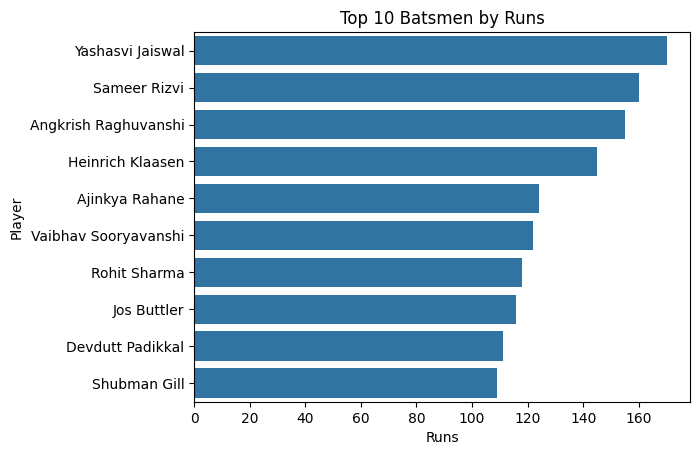

In [0]:
%python
import matplotlib.pyplot as plt
import seaborn as sns

top10 = top_batsmen.head(10)

plt.figure()
sns.barplot(x=top10.values, y=top10.index)
plt.title("Top 10 Batsmen by Runs")
plt.xlabel("Runs")
plt.ylabel("Player")
plt.show()

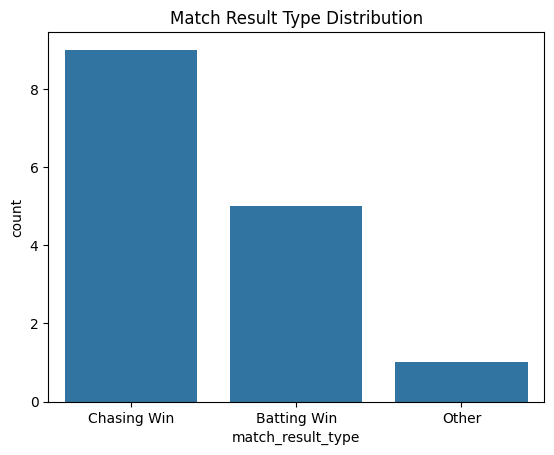

In [0]:
%python
plt.figure()
sns.countplot(data=matches, x='match_result_type')
plt.title("Match Result Type Distribution")
plt.show()

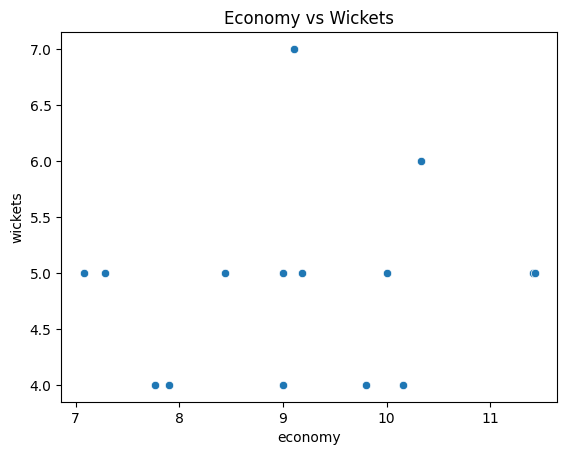

In [0]:
%python
plt.figure()
sns.scatterplot(data=bowling, x='economy', y='wickets')
plt.title("Economy vs Wickets")
plt.show()

In [0]:
%python
spark.createDataFrame(matches).write.mode('overwrite').saveAsTable('workspace.default.matches_cleaned')
spark.createDataFrame(deliveries).write.mode('overwrite').saveAsTable('workspace.default.deliveries_cleaned')

In [0]:
--Total matches played
SELECT COUNT(*) FROM workspace.`ipl2026-completedataset`.matches;

COUNT(*)
15


In [0]:
--Total wins by each team

SELECT match_winner, COUNT(*) AS total_wins
FROM workspace.default.matches_cleaned
GROUP BY match_winner
ORDER BY total_wins DESC;

match_winner,total_wins
RR,3
LSG,2
DC,2
PBKS,2
RCB,2
MI,1
SRH,1
null,1
GT,1


In [0]:
--Points table ranking
SELECT team, matches, wins, points, nrr
FROM workspace.`ipl2026-completedataset`.points_table
ORDER BY points DESC, nrr DESC;

team,matches,wins,points,nrr
Rajasthan Royals,3,3,6,2.403
Punjab Kings,3,2,5,0.637
Royal Challengers Bengaluru,2,2,4,2.501
Delhi Capitals,3,2,4,0.811
Lucknow Super Giants,3,2,4,-0.359
Sunrisers Hyderabad,3,1,2,0.275
Gujarat Titans,3,1,2,-0.27
Mumbai Indians,3,1,2,-0.715
Kolkata Knight Riders,4,0,1,-1.315
Chennai Super Kings,3,0,0,-2.517


In [0]:
--Top batsmen (total runs)
SELECT striker, SUM(runs_of_bat) AS total_runs
FROM workspace.default.deliveries_cleaned
GROUP BY striker
ORDER BY total_runs DESC
LIMIT 10;

striker,total_runs
Yashasvi Jaiswal,170
Sameer Rizvi,160
Angkrish Raghuvanshi,155
Heinrich Klaasen,145
Ajinkya Rahane,124
Vaibhav Sooryavanshi,122
Rohit Sharma,118
Jos Buttler,116
Devdutt Padikkal,111
Shubman Gill,109


In [0]:
--Top bowlers (wickets)
SELECT bowler, COUNT(*) AS wickets
FROM workspace.default.deliveries_cleaned
WHERE wicket_type IS NOT NULL
GROUP BY bowler
ORDER BY wickets DESC
LIMIT 10;

bowler,wickets
Ravi Bishnoi,8
Prasidh Krishna,7
Prince Yadav,6
Jacob Duffy,6
Mukesh Kumar,6
Vaibhav Arora,5
Rashid Khan,5
Vijaykumar Vyshak,5
Blessing Muzarabani,5
Anshul Kamboj,5


In [0]:
--Strike rate calculation
SELECT striker,
SUM(runs_of_bat) * 100.0 / COUNT(*) AS strike_rate
FROM workspace.default.deliveries_cleaned
GROUP BY striker
ORDER BY strike_rate DESC;

striker,strike_rate
Corbin Bosch,275.00000000000000
Jasprit Bumrah,250.00000000000000
Sunil Narine,240.00000000000000
Vaibhav Sooryavanshi,234.61538461538462
Tim David,232.43243243243243
Priyansh Arya,230.00000000000000
Rajat Patidar,225.71428571428571
Xavier Bartlett,220.00000000000000
Devdutt Padikkal,198.21428571428571
Finn Allen,195.12195121951220


In [0]:
--Dot balls analysis
SELECT bowler, COUNT(*) AS dot_balls
FROM workspace.default.deliveries_cleaned
WHERE (runs_of_bat + extras) = 0
GROUP BY bowler
ORDER BY dot_balls DESC;

bowler,dot_balls
Mohammed Shami,38
Mukesh Kumar,28
Lungi Ngidi,28
Jofra Archer,28
Kagiso Rabada,27
Vaibhav Arora,27
Prasidh Krishna,27
Sunil Narine,26
Khaleel Ahmed,26
Rashid Khan,24


In [0]:
--Matches with venue details
SELECT m.match_id, m.team1, m.team2, v.country, v.city
FROM workspace.default.matches_cleaned m
JOIN workspace.`ipl2026-completedataset`.venues v ON m.venue = v.country;

match_id,team1,team2,country,city


In [0]:
--Team performance with points
SELECT p.team, p.points, COUNT(m.match_id) AS matches_played
FROM workspace.`ipl2026-completedataset`.points_table p
LEFT JOIN workspace.default.matches_cleaned m ON p.team = m.match_winner
GROUP BY p.team, p.points
ORDER BY p.points DESC;

team,points,matches_played
Rajasthan Royals,6,0
Punjab Kings,5,0
Royal Challengers Bengaluru,4,0
Delhi Capitals,4,0
Lucknow Super Giants,4,0
Gujarat Titans,2,0
Sunrisers Hyderabad,2,0
Mumbai Indians,2,0
Kolkata Knight Riders,1,0
Chennai Super Kings,0,0


In [0]:
--Advanced SQL Queries
--Best all-rounders (runs + wickets)
SELECT d.batting_team AS player,
       SUM(d.runs_of_bat) AS runs,
       COUNT(CASE WHEN d.wicket_type IS NOT NULL THEN 1 END) AS wickets
FROM workspace.default.deliveries_cleaned d
GROUP BY d.batting_team
HAVING runs > 100 AND wickets > 5
ORDER BY runs DESC;

player,runs,wickets
SRH,560,28
KKR,558,20
GT,546,18
CSK,504,25
MI,487,20
DC,485,16
RR,462,11
LSG,457,22
RCB,427,8
PBKS,362,12


In [0]:
--Win percentage by team
SELECT team,
       (wins * 100.0 /matches ) AS win_percentage
FROM workspace.`ipl2026-completedataset`.points_table
ORDER BY win_percentage DESC;

team,win_percentage
Royal Challengers Bengaluru,100.00000000000000
Rajasthan Royals,100.00000000000000
Lucknow Super Giants,66.66666666666667
Delhi Capitals,66.66666666666667
Punjab Kings,66.66666666666667
Sunrisers Hyderabad,33.33333333333333
Mumbai Indians,33.33333333333333
Gujarat Titans,33.33333333333333
Kolkata Knight Riders,0E-14
Chennai Super Kings,0E-14


In [0]:
--Venue-wise wins
SELECT v._rescued_data, m.match_winner, COUNT(*) AS wins
FROM workspace.default.matches_cleaned m
JOIN  workspace.`ipl2026-completedataset`.venues v ON m.venue = v._rescued_data
GROUP BY v._rescued_data, m.match_winner
ORDER BY wins DESC;

_rescued_data,match_winner,wins
